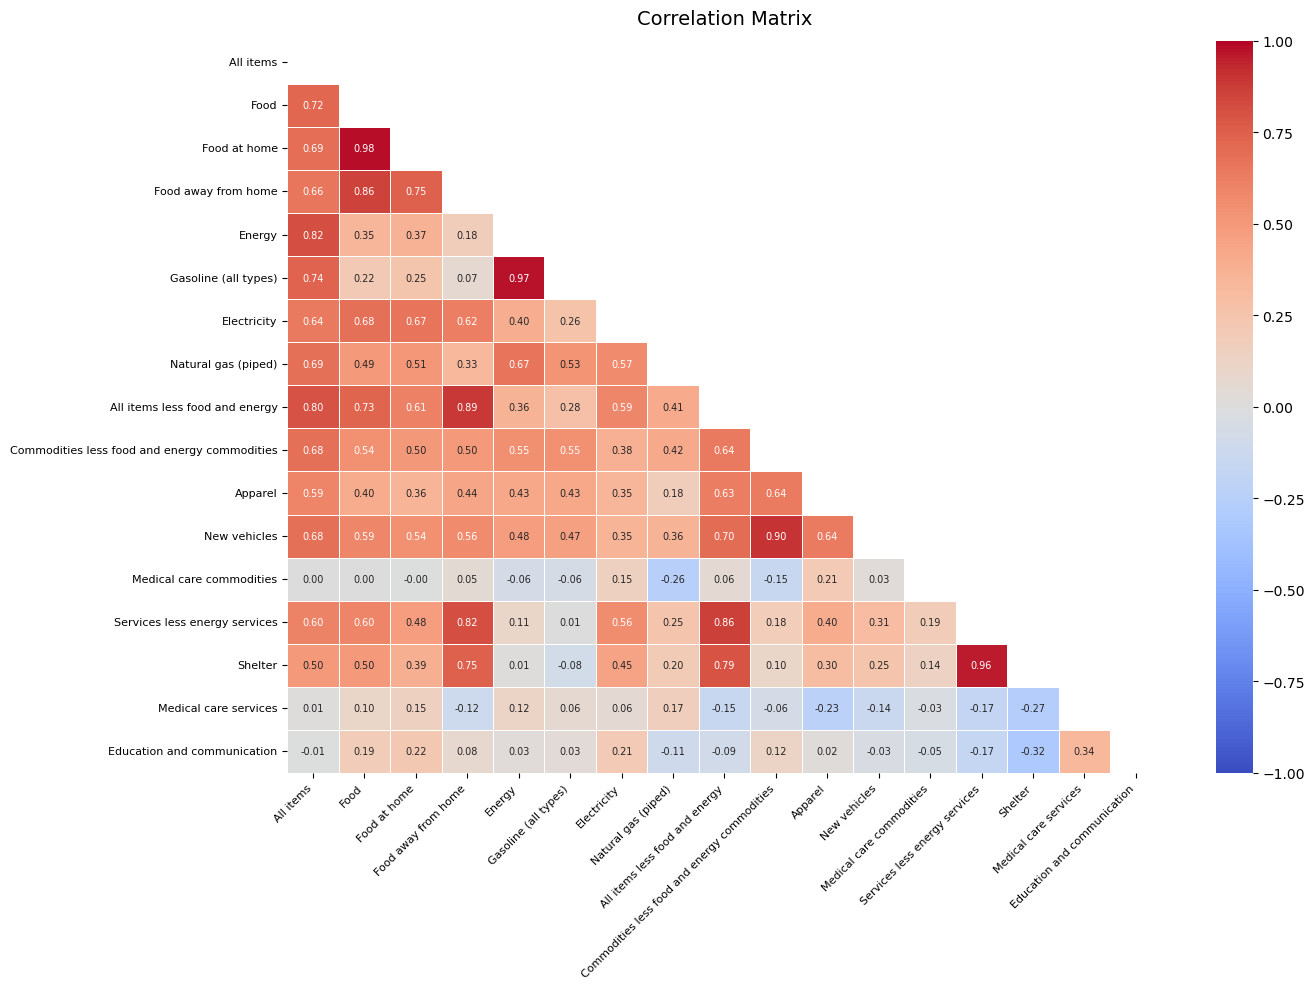


Highly correlated feature pairs (|r| >= 0.85):
-------------------------------------------------------
                     Feature A                                    Feature B  Correlation
                  Food at home                                         Food     0.980058
          Gasoline (all types)                                       Energy     0.973313
                       Shelter                Services less energy services     0.960394
                  New vehicles Commodities less food and energy commodities     0.904286
All items less food and energy                          Food away from home     0.888794
 Services less energy services               All items less food and energy     0.859883
           Food away from home                                         Food     0.855195


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load & Clean ---
df = pd.read_csv("Project2-RawData.csv")

# Drop the Month column (non-numeric)
df = df.drop(columns=["Month", "UMCSENT"])

# Strip % signs and convert to float
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.replace("%", "").astype(float)

# --- Correlation Matrix ---
corr = df.corr()

# --- Plot ---
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (redundant)

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 7}
)

plt.title("Correlation Matrix", fontsize=14, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# --- Print high-correlation pairs (|r| >= 0.85, excluding self-correlations) ---
print("\nHighly correlated feature pairs (|r| >= 0.85):")
print("-" * 55)

threshold = 0.85
pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
        .stack()
        .reset_index()
)
pairs.columns = ["Feature A", "Feature B", "Correlation"]
high_corr = pairs[pairs["Correlation"].abs() >= threshold].sort_values("Correlation", ascending=False)

if high_corr.empty:
    print("No pairs above threshold.")
else:
    print(high_corr.to_string(index=False))